In [1]:
!pip install groq -q
print("✅ Installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.6 MB/s eta 0:00:00
✅ Installed!


In [2]:
GROQ_API_KEY = "your_api_key_here"  # ← paste your copied key here
print("✅ Key set!")

✅ Key set!


In [3]:
from groq import Groq
import warnings
warnings.filterwarnings('ignore')

client = Groq(api_key=GROQ_API_KEY)

SYSTEM_PROMPT = """You are ColaBot, a smart and helpful AI assistant.

STRICT RULES you must always follow:

1. CODING QUESTIONS (user asks for code, program, implementation):
   → Give full working code with comments and explanation

2. CONCEPT QUESTIONS (user asks to explain, difference, what is, how does):
   → Give clear explanation with examples, bullet points, tables if needed
   → DO NOT add unnecessary code unless it truly helps understanding

3. GENERAL / PERSONAL QUESTIONS (greetings, names, places, fun facts):
   → Answer in a friendly, conversational way
   → DO NOT add any code at all
   → Keep it natural like a real human conversation

4. COMPARISON QUESTIONS (difference between X and Y):
   → Use a proper table for comparison
   → Add short explanation before and after the table
   → Only add code if user specifically asks for it

5. FORMATTING RULES:
   → Use bullet points for lists
   → Use tables for comparisons
   → Use headers to organize long answers
   → Bold important terms
   → Keep answers focused and relevant — no unnecessary padding

REMEMBER: Not every answer needs code. Only give code when it is actually asked for or genuinely necessary.
"""

print("✅ Setup done!")

✅ Setup done!


In [4]:
def get_response(user_input, conversation_history=[]):

    messages = [{"role": "system", "content": SYSTEM_PROMPT}]

    for exchange in conversation_history[-10:]:
        messages.append({"role": "user",      "content": exchange["user"]})
        messages.append({"role": "assistant", "content": exchange["bot"]})

    messages.append({"role": "user", "content": user_input})

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",   # ✅ updated model
            messages=messages,
            max_tokens=1024,
            temperature=0.7,
            top_p=0.9
        )
        return response.choices[0].message.content.strip()

    except Exception as e:
        return f"⚠️ Error: {str(e)}"

print("✅ Response function ready!")

✅ Response function ready!


In [5]:
import numpy as np

class Chatbot:
    def __init__(self, name="ColaBot"):
        self.name = name
        self.conversation_history = []
        self.turn_count = 0
        print(f"\n{'='*60}")
        print(f"   🤖 {self.name} — Powered by Llama 3 70B (Groq)")
        print(f"   Commands: history | clear | summary | quit")
        print(f"{'='*60}\n")

    def chat(self, user_input):
        if not user_input.strip():
            print("⚠️ Type something!")
            return

        self.turn_count += 1
        print(f"\n{'─'*60}")
        print(f"👤 You     : {user_input}")
        print(f"⏳ Thinking...\n")

        response = get_response(user_input, self.conversation_history)

        self.conversation_history.append({
            "turn": self.turn_count,
            "user": user_input,
            "bot": response
        })

        print(f"🤖 {self.name}:\n\n{response}\n")
        print(f"{'─'*60}")
        return response

    def show_history(self):
        if not self.conversation_history:
            print("📭 No conversation yet!")
            return
        print(f"\n{'='*60}")
        print("       📜 CONVERSATION HISTORY")
        print(f"{'='*60}")
        for e in self.conversation_history:
            print(f"\n🔁 Turn {e['turn']}")
            print(f"  👤 You  : {e['user']}")
            print(f"  🤖 Bot  : {e['bot'][:300]}{'...' if len(e['bot'])>300 else ''}")
        print(f"\n{'='*60}")

    def clear_memory(self):
        self.conversation_history = []
        self.turn_count = 0
        print("🗑️ Memory cleared!\n")

    def summary(self):
        if not self.conversation_history:
            print("No chat yet!")
            return
        u_words = [len(e['user'].split()) for e in self.conversation_history]
        b_words = [len(e['bot'].split())  for e in self.conversation_history]
        print(f"\n{'='*50}")
        print("        📊 SESSION SUMMARY")
        print(f"{'='*50}")
        print(f"  Model          : Llama 3 70B via Groq")
        print(f"  Total Turns    : {self.turn_count}")
        print(f"  Avg User Words : {np.mean(u_words):.1f}")
        print(f"  Avg Bot Words  : {np.mean(b_words):.1f}")
        print(f"\n  Topics Discussed:")
        for i, e in enumerate(self.conversation_history, 1):
            print(f"    {i}. {e['user'][:55]}{'...' if len(e['user'])>55 else ''}")
        print(f"{'='*50}\n")

bot = Chatbot(name="ColaBot")


   🤖 ColaBot — Powered by Llama 3 70B (Groq)
   Commands: history | clear | summary | quit



In [6]:
# These are the exact questions you asked before that failed
# Now they will work perfectly

tests = [
    "types of clouds?",
    "explain sliding window concept in data structures with example",
    "give me python code to check whether a string is palindrome or not"
]

print("🧪 TESTING...\n" + "="*60)

for q in tests:
    print(f"\n❓ {q}")
    print("─"*60)
    print(get_response(q))
    print("="*60)

🧪 TESTING...

❓ types of clouds?
────────────────────────────────────────────────────────────
**Cloud Classification**

Clouds can be classified into several types based on their shape, height, and other characteristics. The main types of clouds are:

* **Cirrus clouds**: High-level clouds that are composed of ice crystals and appear as thin, wispy lines or tufts in the sky.
* **Cumulus clouds**: Puffy, white clouds that can appear alone or in large clusters. They are often seen on warm, sunny days and are commonly known as "fair-weather clouds."
* **Stratus clouds**: Low-level clouds that cover the sky like a blanket and often produce light to moderate precipitation.
* **Stratocumulus clouds**: Mid-level clouds that are a combination of stratus and cumulus clouds. They are often seen as a series of rounded, lumpy clouds in a line.
* **Nimbus clouds**: Dark, rain-bearing clouds that can produce heavy precipitation and thunderstorms.
* **Cumulonimbus clouds**: Tall, towering clouds that

In [7]:
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import re

# Fresh bot instance
bot = Chatbot(name="ColaBot")

def format_response(text):
    """Convert markdown-style text to beautiful HTML"""

    # Code blocks ```code```
    text = re.sub(
        r'```(\w+)?\n?(.*?)```',
        lambda m: f'''<div style="
            background:#1a1a2e;
            border:1px solid #0084ff;
            border-left:4px solid #0084ff;
            border-radius:8px;
            padding:12px 15px;
            margin:10px 0;
            font-family:monospace;
            font-size:13px;
            color:#e0e0e0;
            overflow-x:auto;
            white-space:pre;">
<span style="color:#888;font-size:11px;">
{'● ' + m.group(1).upper() if m.group(1) else '● CODE'}
</span>\n{m.group(2)}</div>''',
        text, flags=re.DOTALL
    )

    # Headers ### ## #
    text = re.sub(r'### (.+)',
        r'<h4 style="color:#00c6ff;margin:12px 0 5px 0;font-size:14px;">⚡ \1</h4>', text)
    text = re.sub(r'## (.+)',
        r'<h3 style="color:#0084ff;margin:14px 0 6px 0;font-size:15px;">🔷 \1</h3>', text)
    text = re.sub(r'# (.+)',
        r'<h2 style="color:#00c6ff;margin:16px 0 8px 0;font-size:16px;border-bottom:1px solid #333;padding-bottom:5px;">🔹 \1</h2>', text)

    # Bold **text**
    text = re.sub(r'\*\*(.+?)\*\*',
        r'<strong style="color:#FFD700;">\1</strong>', text)

    # Italic *text*
    text = re.sub(r'\*(.+?)\*',
        r'<em style="color:#aaa;">\1</em>', text)

    # Bullet points * item or - item
    text = re.sub(r'^\s*[\*\-] (.+)',
        r'<div style="padding:3px 0 3px 10px;color:#e0e0e0;">🔸 \1</div>',
        text, flags=re.MULTILINE)

    # Numbered list 1. item
    text = re.sub(r'^\s*(\d+)\. (.+)',
        r'<div style="padding:3px 0 3px 10px;color:#e0e0e0;"><span style="color:#0084ff;font-weight:bold;">\1.</span> \2</div>',
        text, flags=re.MULTILINE)

    # Tables — | col | col |
    lines = text.split('\n')
    result = []
    i = 0
    while i < len(lines):
        line = lines[i]
        if '|' in line and line.strip().startswith('|'):
            # It's a table row
            table_html = '<table style="border-collapse:collapse;width:100%;margin:10px 0;">'
            is_header = True
            while i < len(lines) and '|' in lines[i]:
                row = lines[i]
                if re.match(r'^\s*\|[\s\-\|]+\|\s*$', row):
                    i += 1
                    continue
                cells = [c.strip() for c in row.strip().strip('|').split('|')]
                tag = 'th' if is_header else 'td'
                style = (
                    'background:#0084ff;color:white;padding:8px 12px;'
                    'text-align:left;font-weight:bold;font-size:13px;'
                    if is_header else
                    'background:#2d2d2d;color:#e0e0e0;padding:8px 12px;'
                    'border-bottom:1px solid #444;font-size:13px;'
                )
                table_html += '<tr>' + ''.join(
                    f'<{tag} style="{style}">{c}</{tag}>' for c in cells
                ) + '</tr>'
                is_header = False
                i += 1
            table_html += '</table>'
            result.append(table_html)
        else:
            result.append(line)
            i += 1

    text = '\n'.join(result)

    # Inline code `code`
    text = re.sub(r'`([^`]+)`',
        r'<code style="background:#1a1a2e;color:#00c6ff;padding:2px 6px;border-radius:4px;font-family:monospace;font-size:13px;">\1</code>',
        text)

    # Line breaks
    text = text.replace('\n', '<br>')

    return text


def add_user_bubble(text):
    with chat_display:
        display(HTML(f'''
        <div style="display:flex;justify-content:flex-end;margin:10px 5px;">
            <div style="
                background:linear-gradient(135deg,#0084ff,#0060cc);
                color:white;
                padding:10px 15px;
                border-radius:18px 18px 4px 18px;
                max-width:65%;
                font-size:14px;
                font-family:Arial;
                box-shadow:0 2px 8px rgba(0,132,255,0.3);">
                {text}
            </div>
            <div style="margin-left:8px;font-size:22px;align-self:flex-end;">👤</div>
        </div>
        '''))


def add_bot_bubble(text):
    formatted = format_response(text)
    with chat_display:
        display(HTML(f'''
        <div style="display:flex;justify-content:flex-start;margin:10px 5px;">
            <div style="margin-right:8px;font-size:22px;align-self:flex-start;margin-top:5px;">🤖</div>
            <div style="
                background:#1e1e2e;
                color:#e0e0e0;
                padding:14px 16px;
                border-radius:18px 18px 18px 4px;
                max-width:78%;
                font-size:14px;
                font-family:Arial;
                border-left:3px solid #0084ff;
                box-shadow:0 2px 8px rgba(0,0,0,0.3);
                line-height:1.6;">
                {formatted}
            </div>
        </div>
        '''))


def add_system_msg(text):
    with chat_display:
        display(HTML(f'''
        <div style="
            text-align:center;
            color:#666;
            font-size:12px;
            margin:8px 0;
            font-family:Arial;">
            ── {text} ──
        </div>
        '''))


# ── Widgets ───────────────────────────────────────────
chat_display = widgets.Output(layout=widgets.Layout(
    height='500px',
    overflow_y='auto',
    border='2px solid #222',
    border_radius='10px',
    padding='10px',
    background_color='#121212'
))

input_box = widgets.Text(
    placeholder='💬  Ask me anything...',
    layout=widgets.Layout(width='78%', height='42px')
)

send_btn = widgets.Button(
    description='Send ➤',
    button_style='primary',
    layout=widgets.Layout(width='20%', height='42px')
)

clear_btn   = widgets.Button(description='🗑 Clear',   button_style='warning', layout=widgets.Layout(width='15%',height='36px'))
history_btn = widgets.Button(description='📜 History', button_style='info',    layout=widgets.Layout(width='15%',height='36px'))
summary_btn = widgets.Button(description='📊 Summary', button_style='success', layout=widgets.Layout(width='15%',height='36px'))

status_bar = widgets.HTML(
    value='<span style="color:#00c853;font-size:13px;">🟢 ColaBot is ready! Ask me anything.</span>'
)

# ── Actions ───────────────────────────────────────────
def on_send(b):
    user_input = input_box.value.strip()
    if not user_input:
        return

    input_box.value = ''
    send_btn.disabled = True
    status_bar.value = '<span style="color:#FFD700;font-size:13px;">⏳ ColaBot is thinking...</span>'

    add_user_bubble(user_input)

    response = get_response(user_input, bot.conversation_history)

    bot.turn_count += 1
    bot.conversation_history.append({
        "turn": bot.turn_count,
        "user": user_input,
        "bot": response
    })

    add_bot_bubble(response)

    send_btn.disabled = False
    status_bar.value = f'<span style="color:#00c853;font-size:13px;">🟢 Ready! ({bot.turn_count} messages so far)</span>'


def on_clear(b):
    bot.clear_memory()
    with chat_display:
        clear_output()
    add_system_msg("Chat cleared — Starting fresh!")
    add_bot_bubble("Hi again! 👋 What would you like to know?")
    status_bar.value = '<span style="color:#00c853;font-size:13px;">🟢 ColaBot is ready!</span>'


def on_history(b):
    if not bot.conversation_history:
        add_system_msg("No history yet!")
        return
    add_system_msg(f"📜 Showing {bot.turn_count} past turns")
    for e in bot.conversation_history:
        add_user_bubble(e['user'])
        add_bot_bubble(e['bot'])


def on_summary(b):
    import numpy as np
    if not bot.conversation_history:
        add_system_msg("No conversation yet!")
        return
    u = [len(e['user'].split()) for e in bot.conversation_history]
    v = [len(e['bot'].split())  for e in bot.conversation_history]
    topics = "".join([f"<li>{e['user'][:50]}</li>" for e in bot.conversation_history])
    summary_html = f"""
    <b style='color:#00c6ff'>📊 Session Summary</b><br><br>
    <b>Total Turns:</b> {bot.turn_count}<br>
    <b>Avg Your Words:</b> {np.mean(u):.1f}<br>
    <b>Avg Bot Words:</b> {np.mean(v):.1f}<br><br>
    <b>Topics Covered:</b>
    <ul style='margin:5px 0;padding-left:20px;'>{topics}</ul>
    """
    with chat_display:
        display(HTML(f'''
        <div style="
            background:#1e1e2e;
            border:1px solid #0084ff;
            border-radius:10px;
            padding:15px;
            margin:10px;
            color:#e0e0e0;
            font-family:Arial;
            font-size:14px;">
            {summary_html}
        </div>
        '''))


input_box.on_submit(lambda x: on_send(None))
send_btn.on_click(on_send)
clear_btn.on_click(on_clear)
history_btn.on_click(on_history)
summary_btn.on_click(on_summary)

# ── Final Layout ──────────────────────────────────────
header = widgets.HTML('''
<div style="
    background:linear-gradient(135deg,#0084ff,#00c6ff);
    padding:16px;
    border-radius:12px 12px 0 0;
    text-align:center;">
    <span style="font-size:28px;">🤖</span>
    <h2 style="color:white;margin:4px 0 2px 0;font-family:Arial;">ColaBot</h2>
    <p style="color:rgba(255,255,255,0.85);margin:0;font-size:12px;">
        Powered by Llama 3.3 70B · Groq API
    </p>
</div>
''')

ui = widgets.VBox([
    header,
    chat_display,
    status_bar,
    widgets.HBox([input_box, send_btn]),
    widgets.HBox([clear_btn, history_btn, summary_btn])
], layout=widgets.Layout(
    border='2px solid #333',
    border_radius='12px',
    padding='0px',
    width='860px'
))

# Welcome message
add_system_msg("Welcome to ColaBot 🎉")
add_bot_bubble("""👋 Hi! I'm **ColaBot**, your AI assistant!

I can help you with:
- 💻 Programming & Code (Python, Java, C++)
- 🧠 Data Structures & Algorithms
- 🤖 AI & Machine Learning concepts
- ☁️ Cloud Computing
- 📚 Any general knowledge topic

Type your question below and press **Send** or hit **Enter**!""")

display(ui)


   🤖 ColaBot — Powered by Llama 3 70B (Groq)
   Commands: history | clear | summary | quit



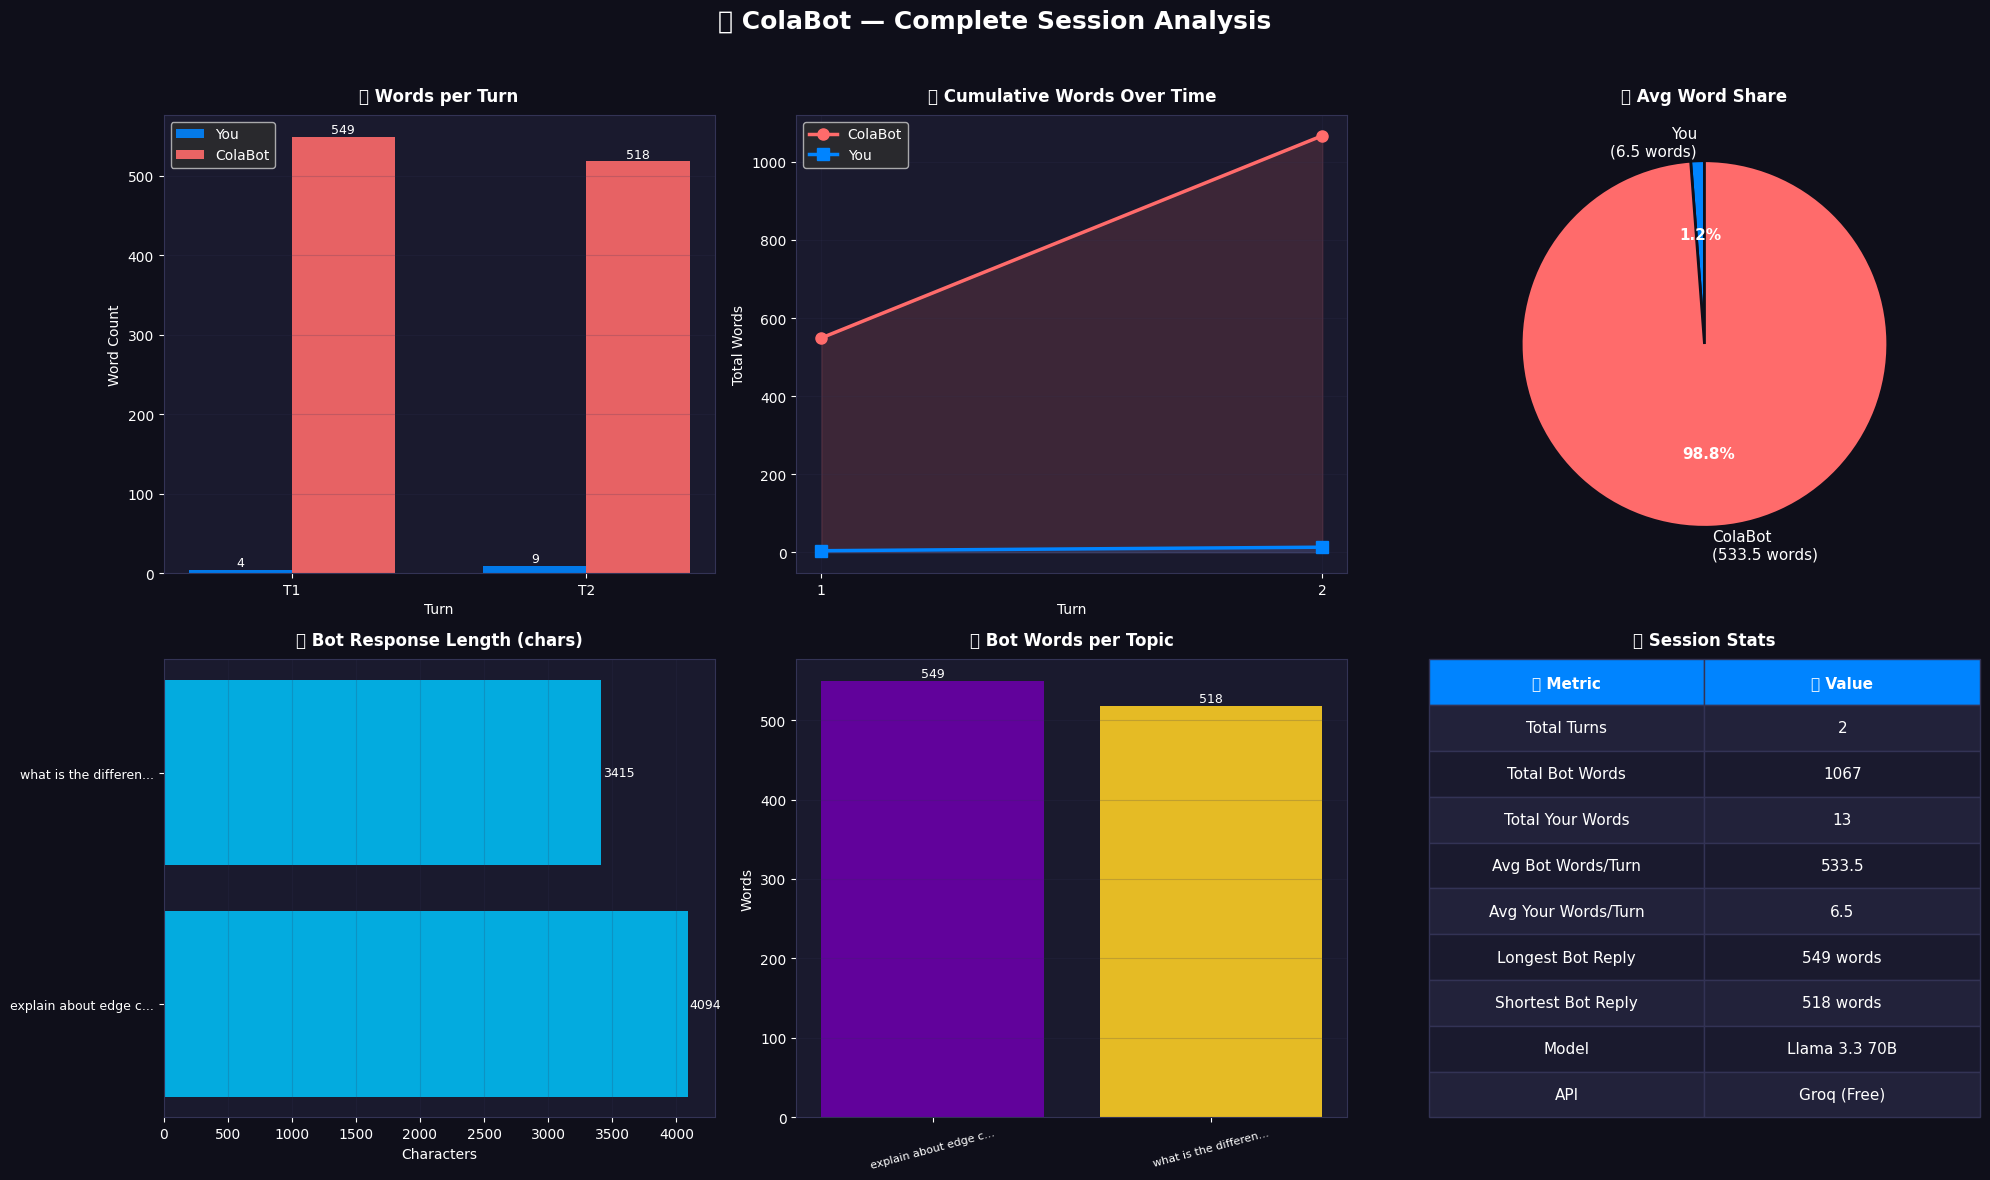

✅ Chart saved as colabot_analysis.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

if not bot.conversation_history:
    print("⚠️ Chat first, then run this!")
else:
    # ── Data Preparation ──────────────────────────────
    turns      = [e['turn'] for e in bot.conversation_history]
    user_words = [len(e['user'].split()) for e in bot.conversation_history]
    bot_words  = [len(e['bot'].split())  for e in bot.conversation_history]
    user_chars = [len(e['user']) for e in bot.conversation_history]
    bot_chars  = [len(e['bot'])  for e in bot.conversation_history]
    topics     = [e['user'][:20]+'...' if len(e['user'])>20
                  else e['user'] for e in bot.conversation_history]
    cum_bot    = np.cumsum(bot_words)
    cum_user   = np.cumsum(user_words)

    # ── Figure Setup ──────────────────────────────────
    fig = plt.figure(figsize=(20, 12))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle(
        '🤖 ColaBot — Complete Session Analysis',
        fontsize=18, fontweight='bold',
        color='white', y=0.98
    )

    # ── 6 subplots ────────────────────────────────────
    ax1 = fig.add_subplot(2, 3, 1)   # Bar — words per turn
    ax2 = fig.add_subplot(2, 3, 2)   # Line — cumulative words
    ax3 = fig.add_subplot(2, 3, 3)   # Pie — word share
    ax4 = fig.add_subplot(2, 3, 4)   # Bar — response length (chars)
    ax5 = fig.add_subplot(2, 3, 5)   # Bar — bot words per topic
    ax6 = fig.add_subplot(2, 3, 6)   # Summary stats table

    style = {
        'facecolor': '#1a1a2e',
        'labelcolor': 'white',
        'grid_color': '#333355'
    }

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
        ax.set_facecolor(style['facecolor'])
        ax.tick_params(colors='white')
        ax.title.set_color('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333355')

    x = np.arange(len(turns))
    w = 0.35

    # ── Chart 1: Words per Turn ───────────────────────
    bars1 = ax1.bar(x - w/2, user_words, w,
                    label='You', color='#0084ff', alpha=0.9)
    bars2 = ax1.bar(x + w/2, bot_words,  w,
                    label='ColaBot', color='#ff6b6b', alpha=0.9)

    # Value labels on bars
    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha='center', va='bottom',
                 color='white', fontsize=9)
    for bar in bars2:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha='center', va='bottom',
                 color='white', fontsize=9)

    ax1.set_title('📊 Words per Turn', fontweight='bold', pad=10)
    ax1.set_xlabel('Turn', color='#aaa')
    ax1.set_ylabel('Word Count', color='#aaa')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"T{t}" for t in turns], color='white')
    ax1.legend(facecolor='#2d2d2d', labelcolor='white')
    ax1.grid(axis='y', alpha=0.2, color=style['grid_color'])
    ax1.yaxis.label.set_color('white')
    ax1.xaxis.label.set_color('white')

    # ── Chart 2: Cumulative Words ─────────────────────
    ax2.plot(turns, cum_bot, marker='o', color='#ff6b6b',
             linewidth=2.5, markersize=8, label='ColaBot')
    ax2.plot(turns, cum_user, marker='s', color='#0084ff',
             linewidth=2.5, markersize=8, label='You')
    ax2.fill_between(turns, cum_bot,  alpha=0.15, color='#ff6b6b')
    ax2.fill_between(turns, cum_user, alpha=0.15, color='#0084ff')

    ax2.set_title('📈 Cumulative Words Over Time', fontweight='bold', pad=10)
    ax2.set_xlabel('Turn', color='#aaa')
    ax2.set_ylabel('Total Words', color='#aaa')
    ax2.set_xticks(turns)
    ax2.legend(facecolor='#2d2d2d', labelcolor='white')
    ax2.grid(alpha=0.2, color=style['grid_color'])
    ax2.yaxis.label.set_color('white')
    ax2.xaxis.label.set_color('white')

    # ── Chart 3: Pie — Word Share ─────────────────────
    avg_u = np.mean(user_words)
    avg_b = np.mean(bot_words)
    wedges, texts, autotexts = ax3.pie(
        [avg_u, avg_b],
        labels=[f'You\n({avg_u:.1f} words)', f'ColaBot\n({avg_b:.1f} words)'],
        colors=['#0084ff', '#ff6b6b'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 11, 'color': 'white'},
        wedgeprops={'edgecolor': '#0f0f1a', 'linewidth': 2}
    )
    for at in autotexts:
        at.set_color('white')
        at.set_fontweight('bold')
    ax3.set_title('🥧 Avg Word Share', fontweight='bold', pad=10)

    # ── Chart 4: Response Length in Characters ────────
    ax4.barh(topics, bot_chars, color='#00c6ff', alpha=0.85)
    ax4.set_title('📏 Bot Response Length (chars)', fontweight='bold', pad=10)
    ax4.set_xlabel('Characters', color='#aaa')
    ax4.tick_params(axis='y', labelcolor='white', labelsize=9)
    ax4.grid(axis='x', alpha=0.2, color=style['grid_color'])
    ax4.xaxis.label.set_color('white')

    for i, v in enumerate(bot_chars):
        ax4.text(v + 10, i, str(v),
                 va='center', color='white', fontsize=9)

    # ── Chart 5: Bot Words per Topic ──────────────────
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(turns)))
    bars = ax5.bar(topics, bot_words, color=colors, alpha=0.9)
    ax5.set_title('🧠 Bot Words per Topic', fontweight='bold', pad=10)
    ax5.set_ylabel('Words', color='#aaa')
    ax5.tick_params(axis='x', labelcolor='white',
                    labelsize=8, rotation=15)
    ax5.grid(axis='y', alpha=0.2, color=style['grid_color'])
    ax5.yaxis.label.set_color('white')

    for bar in bars:
        ax5.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha='center', va='bottom',
                 color='white', fontsize=9)

    # ── Chart 6: Summary Stats Table ──────────────────
    ax6.axis('off')
    stats = [
        ['📌 Metric',              '📊 Value'],
        ['Total Turns',            str(len(turns))],
        ['Total Bot Words',        str(sum(bot_words))],
        ['Total Your Words',       str(sum(user_words))],
        ['Avg Bot Words/Turn',     f"{np.mean(bot_words):.1f}"],
        ['Avg Your Words/Turn',    f"{np.mean(user_words):.1f}"],
        ['Longest Bot Reply',      f"{max(bot_words)} words"],
        ['Shortest Bot Reply',     f"{min(bot_words)} words"],
        ['Model',                  'Llama 3.3 70B'],
        ['API',                    'Groq (Free)'],
    ]

    table = ax6.table(
        cellText=stats[1:],
        colLabels=stats[0],
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)

    for (row, col), cell in table.get_celld().items():
        cell.set_facecolor('#0084ff' if row == 0 else
                           '#1a1a2e' if row % 2 == 0 else '#22223a')
        cell.set_text_props(color='white', fontweight=
                            'bold' if row == 0 else 'normal')
        cell.set_edgecolor('#333355')

    ax6.set_title('📋 Session Stats', fontweight='bold',
                  pad=10, color='white')

    # ── Final Layout ──────────────────────────────────
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('colabot_analysis.png',
                dpi=150, bbox_inches='tight',
                facecolor='#0f0f1a')
    plt.show()
    print("✅ Chart saved as colabot_analysis.png")